In [51]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import random

In [47]:
def evaluate_model(model, test_loader, device):
    print("\n📊 Evaluating best model on test set...")

    model.eval()

    all_preds, all_targets, all_probs = [], [], []
    with torch.no_grad():
        for data, targets in tqdm(test_loader, desc="Testing", leave=True):
            data, targets = data.to(device), targets.to(device)
            outputs = model(data)
            probs = F.softmax(outputs, dim=1)
            preds = probs.argmax(1)

            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(targets.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    # Compute metrics
    accuracy = (np.array(all_preds) == np.array(all_targets)).mean() * 100
    print(f"\n✅ Test Accuracy: {accuracy:.4f}%")
    print("\n📋 Classification Report:")
    print(classification_report(all_targets, all_preds, target_names=["AD", "NC"], digits=4))

    return accuracy, all_preds, all_targets, all_probs

In [48]:
def plot_confusion_matrix(all_targets, all_preds):
    cm = confusion_matrix(all_targets, all_preds)
    cm_norm = confusion_matrix(all_targets, all_preds, normalize="true")

    fig, ax = plt.subplots(1, 2, figsize=(12, 5))
    ConfusionMatrixDisplay(cm, display_labels=["AD", "NC"]).plot(ax=ax[0], cmap="Reds", colorbar=False)
    ax[0].set_title("Confusion Matrix (Raw)")

    ConfusionMatrixDisplay(cm_norm, display_labels=["AD", "NC"]).plot(ax=ax[1], cmap="Greens", colorbar=True)
    ax[1].set_title("Normalized Confusion Matrix")

    plt.tight_layout()
    plt.show()

In [49]:
def display_sample_predictions(dataset, num_samples=10):

    print("\n🖼️ Displaying sample predictions from test set...")

    class_names = ["AD", "NC"]

    # Select random samples from test set
    indices = random.sample(range(len(test_ds)), num_samples)
    samples = [test_ds[i] for i in indices]

    fig, axes = plt.subplots(2, 5, figsize=(15, 7))
    fig.suptitle("Sample Test Predictions", fontsize=16)

    for i, (img, true_label) in enumerate(samples):
        ax = axes[i // 5, i % 5]
        model_input = img.unsqueeze(0).to(device)
        with torch.no_grad():
            output = model(model_input)
            prob = F.softmax(output, dim=1).cpu().numpy()[0]
            pred_label = np.argmax(prob)
            confidence = prob[pred_label]

        # Denormalize image
        img_disp = img * 0.271 + 0.263
        img_disp = img_disp.squeeze(0).cpu().numpy()

        ax.imshow(img_disp, cmap="gray")
        ax.axis("off")

        title_color = "green" if pred_label == true_label else "red"
        ax.set_title(
            f"Pred: {class_names[pred_label]}\nTrue: {class_names[true_label]}\nConf: {confidence*100:.1f}%",
            fontsize=10,
            color=title_color,
        )

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
[NbConvertApp] Converting notebook /content/drive/My Drive/Colab Notebooks/Pattern Recognition Project/multi file solution/dataset.ipynb to python
[NbConvertApp] Writing 5544 bytes to /content/drive/My Drive/Colab Notebooks/Pattern Recognition Project/multi file solution/dataset.py
[NbConvertApp] Converting notebook /content/drive/My Drive/Colab Notebooks/Pattern Recognition Project/multi file solution/modules.ipynb to python
[NbConvertApp] Writing 4470 bytes to /content/drive/My Drive/Colab Notebooks/Pattern Recognition Project/multi file solution/modules.py
Using: cuda

📊 Evaluating best model on test set...


Testing: 100%|██████████| 71/71 [00:38<00:00,  1.83it/s]



✅ Test Accuracy: 60.8889%

📋 Classification Report:
              precision    recall  f1-score   support

          AD     0.5647    0.9197    0.6998      4460
          NC     0.7938    0.3035    0.4391      4540

    accuracy                         0.6089      9000
   macro avg     0.6792    0.6116    0.5694      9000
weighted avg     0.6803    0.6089    0.5683      9000



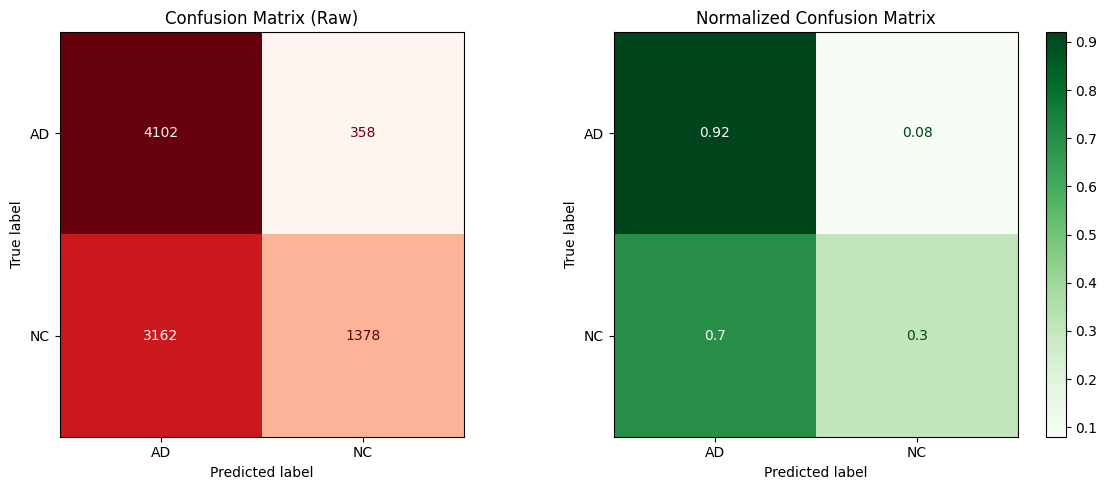


🖼️ Displaying sample predictions from test set...


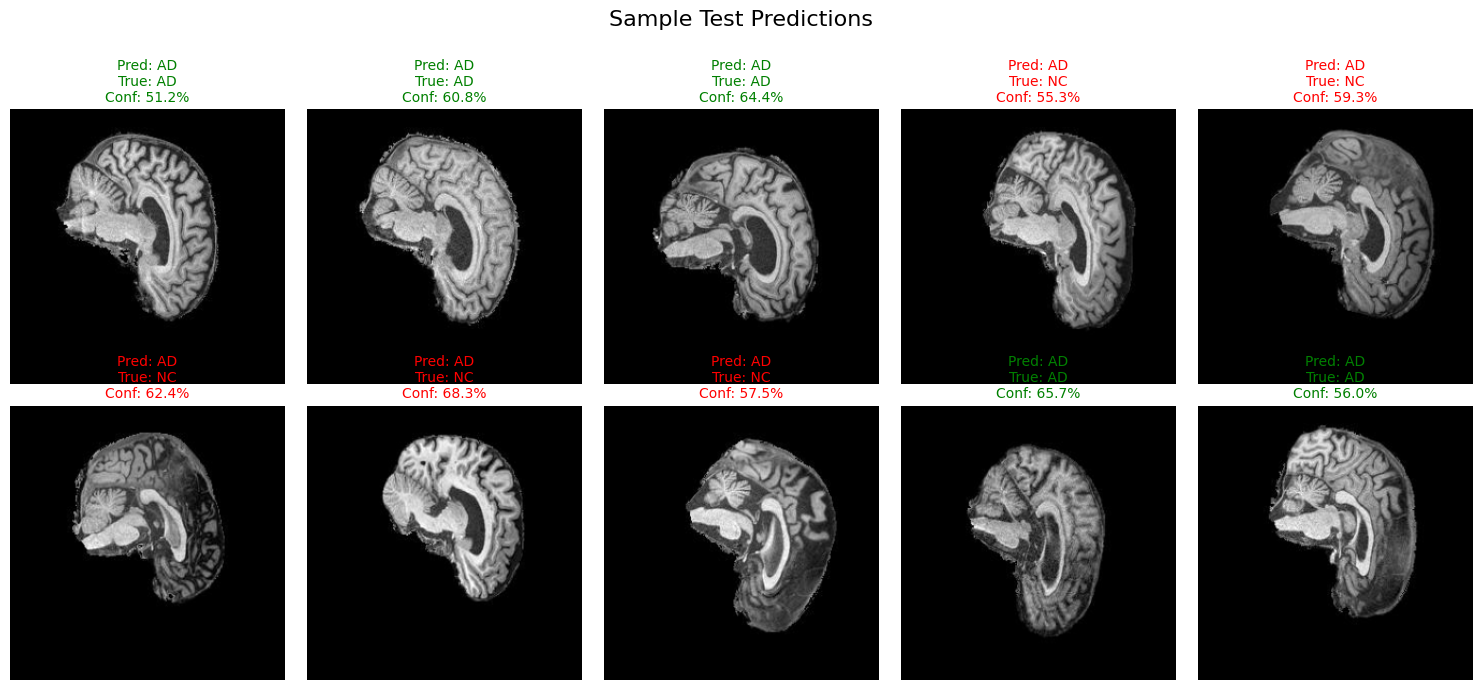

In [50]:
if __name__ == "__main__":

  from google.colab import drive
  drive.mount('/content/drive')

  !jupyter nbconvert "/content/drive/My Drive/Colab Notebooks/Pattern Recognition Project/multi file solution/dataset.ipynb" --to python
  !jupyter nbconvert "/content/drive/My Drive/Colab Notebooks/Pattern Recognition Project/multi file solution/modules.ipynb" --to python

  import sys, os

  py_file_location = "/content/drive/My Drive/Colab Notebooks/Pattern Recognition Project/multi file solution/"
  sys.path.append(os.path.abspath(py_file_location))

  import importlib, dataset, modules
  importlib.reload(dataset)
  importlib.reload(modules)

  from dataset import *
  from modules import *

  device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
  print("Using:", device)

  train_dir = "/content/drive/MyDrive/Colab Notebooks/Pattern Recognition Project/AD_NC/train"
  test_dir  = "/content/drive/MyDrive/Colab Notebooks/Pattern Recognition Project/AD_NC/test"
  save_dir = "/content/drive/MyDrive/Colab Notebooks/Pattern Recognition Project/multi file solution/"

  _, _, test_ds = create_datasets(train_dir, test_dir)
  _, _, test_loader = create_dataloaders(_, _, test_ds)

  model = ConvNeXt(in_chans=1, num_classes=2).to(device)
  model.load_state_dict(torch.load(os.path.join(save_dir, "best_convnext_adni.pth"), map_location=device))

  accuracy, all_preds, all_targets, all_probs = evaluate_model(model, test_loader, device)

  plot_confusion_matrix(all_targets, all_preds)

  display_sample_predictions(test_ds)